In [8]:
import os
os.getcwd()

'/Projects/Bhavesh_project/cct_notebooks'

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict
from sklearn.preprocessing import normalize
import faiss

# Configuration
H5_PATH           = "../embeddings/cct_dinov2l_embeddings_v2.h5" 
SEEN_IN_QUERY     = set()
GALLERY_FRACTION  = 0.75  # 75% of known species stay in the 'database'
ROLLING_WINDOW    = 25
RNG_SEED          = 42

rng = np.random.default_rng(RNG_SEED)

In [8]:
class AdaptiveNCMClassifier:
    def __init__(self, k_factor=0.5):
        self.k_factor = k_factor
        self.prototypes = {}     # {species: mean_vector} (NOT normalized — raw mean)
        self.counts = {}         # {species: count}  — Welford state, never mutated externally
        self.mean_dists = {}     # {species: running mean distance}
        self.m2_dists = {}       # {species: running sum of squared diffs (Welford)}

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _normalized(self, v):
        n = np.linalg.norm(v)
        return v / n if n > 0 else v

    def _dist_to_proto(self, emb, cls):
        """
        Cosine-based distance on the unit sphere:  sqrt(2 - 2·cos)
        Both operands are normalized at query time so the raw prototype
        can be kept un-normalized for numerically stable incremental updates.
        """
        proto_norm = self._normalized(self.prototypes[cls])
        emb_norm   = self._normalized(emb)
        dot = np.clip(np.dot(proto_norm, emb_norm), -1.0, 1.0)
        return np.sqrt(max(0.0, 2.0 - 2.0 * dot))

    # ------------------------------------------------------------------
    # Radius
    # ------------------------------------------------------------------

    def _get_radius(self, cls):
        n = self.counts[cls]
        if n < 2:
            return 0.15

        # Fix 3: guard against tiny negative floats from Welford accumulation
        variance = max(0.0, self.m2_dists[cls] / (n - 1))
        std = np.sqrt(variance)
        base_radius = self.mean_dists[cls] + self.k_factor * std
    
        return base_radius

    # ------------------------------------------------------------------
    # Fit (batch, called once on the gallery)
    # ------------------------------------------------------------------

    def fit(self, g_embs, g_labels):
        unique_classes = np.unique(g_labels)
        for cls in unique_classes:
            cls_embs = g_embs[g_labels == cls]
            n = len(cls_embs)
            self.counts[cls] = n

            # Store the RAW mean as prototype (normalized only when used).
            # Keeping the raw mean lets incremental updates stay consistent —
            # normalization is deferred to query time.
            proto = np.mean(cls_embs, axis=0)
            self.prototypes[cls] = proto   # NOT normalized here

            # Distances use cosine-based metric for consistency with predict()
            proto_norm = self._normalized(proto)
            dots  = np.clip(cls_embs.dot(proto_norm), -1.0, 1.0)
            dists = np.sqrt(np.maximum(0.0, 2.0 - 2.0 * dots))

            self.mean_dists[cls]  = np.mean(dists)
            self.m2_dists[cls]    = np.sum((dists - self.mean_dists[cls]) ** 2)

    # ------------------------------------------------------------------
    # Online update  (Welford on raw prototype)
    # ------------------------------------------------------------------

    def update(self, new_emb, species):
        n = self.counts.get(species, 0)

        if n == 0:
            # Initialise with count = 1 and valid (if trivial) Welford state.
            # The radius formula returns the default for n < 2 until a second
            # sample arrives, which is correct behaviour.
            self.prototypes[species]     = new_emb.copy()
            self.counts[species]         = 1
            self.mean_dists[species]     = 0.0   # distance of emb to itself
            self.m2_dists[species]       = 0.0
            return

        # --- update raw prototype (simple running mean, no normalization) ---
        old_proto = self.prototypes[species]
        new_n     = n + 1
        new_proto = (old_proto * n + new_emb) / new_n
        self.prototypes[species] = new_proto
        self.counts[species]     = new_n

        # --- Welford update on distance to the NEW prototype ---------------
        # One consistent distance per sample, measured against the prototype
        # that is current *after* the update — same reference frame throughout.
        new_dist = self._dist_to_proto(new_emb, species)

        delta  = new_dist - self.mean_dists[species]
        self.mean_dists[species] += delta / new_n
        delta2 = new_dist - self.mean_dists[species]
        self.m2_dists[species]  += delta * delta2

    # ------------------------------------------------------------------
    # Predict
    # ------------------------------------------------------------------

    def predict(self, query_emb):
        species_list = list(self.prototypes.keys())

        # Normalize query once
        query_norm = self._normalized(query_emb)

        # Normalize all prototypes at query time (raw protos stored)
        protos_norm = np.array([self._normalized(self.prototypes[cls])
                                for cls in species_list])

        dots  = np.clip(protos_norm.dot(query_norm), -1.0, 1.0)
        dists = np.sqrt(np.maximum(0.0, 2.0 - 2.0 * dots))

        within_radius = [
            i for i, (cls, dist) in enumerate(zip(species_list, dists))
            if dist <= self._get_radius(cls)
        ]

        if not within_radius:
            nearest_idx = np.argmin(dists)
            return species_list[nearest_idx], True    # is_unknown = True

        best_idx = min(within_radius, key=lambda i: dists[i])
        return species_list[best_idx], False          # is_unknown = False


# ======================================================================
# Experiment loop
# ======================================================================

with h5py.File(H5_PATH, "r") as hf:
    embeddings = normalize(hf["embeddings"][:], norm="l2")
    species    = np.array([s.decode() for s in hf["species"][:]])

all_species    = np.unique(species)
all_species = all_species[all_species != 'car']

species_counts = {sp: np.sum(species == sp) for sp in all_species}
sorted_species = sorted(
    [sp for sp, c in species_counts.items() if c >= 10],
    key=lambda x: species_counts[x]
)

results = []

for target_sp in sorted_species:
    clf = AdaptiveNCMClassifier(k_factor=0.5)

    g_mask = (species != target_sp)
    clf.fit(embeddings[g_mask], species[g_mask])

    q_mask    = (species == target_sp)
    q_embs_sp = embeddings[q_mask]

    # Hold out 20 % of query samples for honest evaluation.
    n_q      = len(q_embs_sp)
    n_train  = max(1, int(0.8 * n_q))
    train_embs = q_embs_sp[:n_train]
    test_embs  = q_embs_sp[n_train:]

    # ------------------------------------------------------------------
    # Pass 1 — Oracle Learning on the TRAINING split
    # Accuracy is recorded BEFORE any update so the metric reflects
    # real pre-update performance (Bug 2 fix).
    # ------------------------------------------------------------------
    correct_p1 = 0
    for emb in train_embs:
        pred, is_unknown = clf.predict(emb)

        # Evaluate BEFORE update — unchanged
        if not is_unknown and pred == target_sp:
            correct_p1 += 1

        # Always update the target prototype, not just on misses
        clf.update(emb, target_sp)

    # ------------------------------------------------------------------
    # Pass 2 — Inference Only on the held-out TEST split
    # ------------------------------------------------------------------
    correct_p2 = 0
    for emb in test_embs:
        pred, is_unknown = clf.predict(emb)
        if not is_unknown and pred == target_sp:
            correct_p2 += 1

    n_test = len(test_embs)
    results.append({
        "species":   target_sp,
        "count":     species_counts[target_sp],
        "pass1_acc": correct_p1 / n_train,
        "pass2_acc": correct_p2 / n_test if n_test > 0 else 0.0,
        "n_train":   n_train,
        "n_test":    n_test,
    })

In [9]:
print((all_species))

['badger' 'bat' 'bird' 'bobcat' 'cat' 'cow' 'coyote' 'deer' 'dog' 'fox'
 'insect' 'lizard' 'mountain_lion' 'opossum' 'pig' 'rabbit' 'raccoon'
 'rodent' 'skunk' 'squirrel']


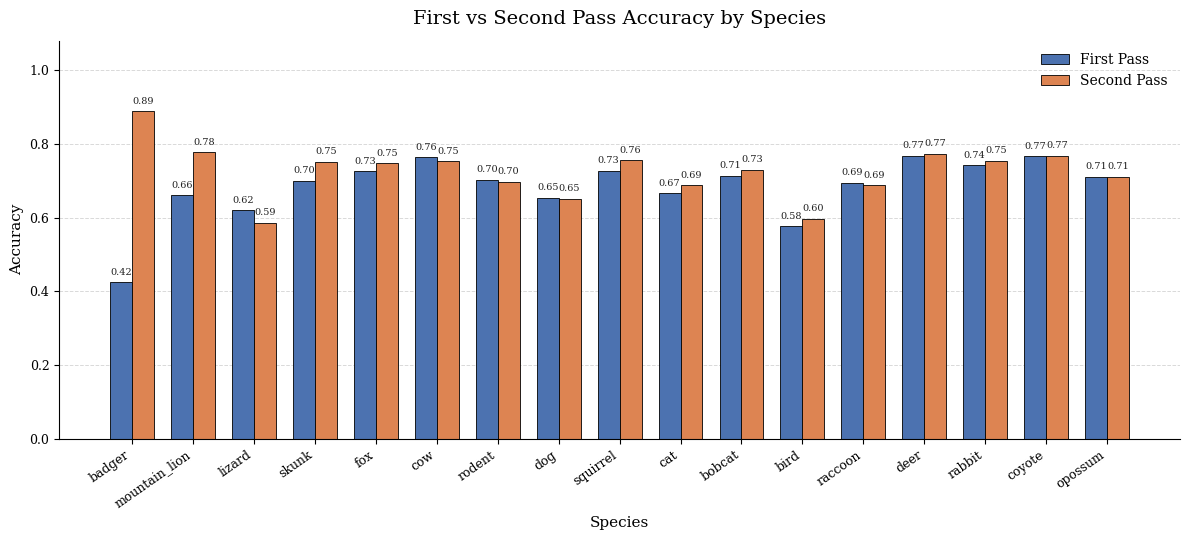

Saved → stress_test_accuracy_publication


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams

# ── Typography ──────────────────────────────────────────────────────────────
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42

# ── Publication-friendly palette ────────────────────────────────────────────
ACCENT1   = '#4C72B0'   # muted blue
ACCENT2   = '#DD8452'   # muted orange
GRID      = '#D9D9D9'
TEXT_MAIN = '#222222'

# ── Data ────────────────────────────────────────────────────────────────────
labels    = [r["species"]   for r in results]
pass1_acc = [r["pass1_acc"] for r in results]
pass2_acc = [r["pass2_acc"] for r in results]

x = np.arange(len(labels))
width = 0.36

# ── Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Bars ────────────────────────────────────────────────────────────────────
bars1 = ax.bar(
    x - width / 2,
    pass1_acc,
    width,
    color=ACCENT1,
    edgecolor='black',
    linewidth=0.6,
    label='First Pass'
)

bars2 = ax.bar(
    x + width / 2,
    pass2_acc,
    width,
    color=ACCENT2,
    edgecolor='black',
    linewidth=0.6,
    label='Second Pass'
)

# ── Value labels ────────────────────────────────────────────────────────────
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.015,
            f'{h:.2f}',
            ha='center',
            va='bottom',
            fontsize=7,
            color=TEXT_MAIN
        )

# ── Grid & spines ───────────────────────────────────────────────────────────
ax.yaxis.grid(True, linestyle='--', linewidth=0.7, color=GRID)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# ── Labels & ticks ──────────────────────────────────────────────────────────
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_xlabel('Species', fontsize=11)

ax.set_ylim(0, 1.08)
ax.set_yticks(np.arange(0, 1.1, 0.2))

ax.set_xticks(x)
ax.set_xticklabels(
    labels,
    rotation=35,
    ha='right',
    fontsize=9
)

ax.tick_params(axis='y', labelsize=9)

# ── Title ───────────────────────────────────────────────────────────────────
ax.set_title(
    'First vs Second Pass Accuracy by Species',
    fontsize=14,
    pad=12
)

# ── Legend ──────────────────────────────────────────────────────────────────
ax.legend(
    frameon=False,
    fontsize=10,
    loc='upper right'
)

# ── Layout & save ───────────────────────────────────────────────────────────
plt.tight_layout()

plt.savefig(
    'plots/stress_test_accuracy_publication.pdf',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved → stress_test_accuracy_publication")